# 联合分布与期望协方差

学习目标：从联合表与连续密度计算边缘分布、条件分布和期望，用协方差描述共同变化，并把二维正态的协方差矩阵与样本形状、等密度椭圆联系起来。

前置知识：随机变量、条件概率、求和、定积分、矩阵乘法、二次型与特征分解；Python 函数与 NumPy 数组操作。

运行环境：Python 3.12、NumPy 2.5、SciPy 1.18、Matplotlib 3.11。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

阅读安排：第 1～2 节把联合表和联合密度对应起来；第 3～5 节理解期望、协方差及矩阵条件；第 6～8 节学习条件期望、二维正态与综合计算。内容可分三次完成，每次保留手算式，再用代码核对。

## 1 从联合概率表开始

### 1.1 同时记录两个随机变量

考虑一个教学模型：每次抽取一项任务，$X\in\{0,1,2\}$ 表示需要返工的次数，$Y\in\{0,1\}$ 表示是否延期。假设联合概率已知如下。表内是模型概率，不是一次抽样的频数。

| $X\backslash Y$ | $Y=0$ | $Y=1$ |
| --- | --- | --- |
| $X=0$ | $1/10$ | $1/10$ |
| $X=1$ | $1/10$ | $2/10$ |
| $X=2$ | $1/10$ | $4/10$ |

联合概率质量函数（joint PMF）$p_{XY}(x,y)=P(X=x,Y=y)$ 给出两个条件同时成立的概率。各项非负，全部相加为 1；不在表中的取值组合概率为 0。

事件的概率等于对应格子的概率之和。例如“至少返工一次且延期”的概率为 $2/10+4/10=0.6$。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import dblquad, quad
from scipy.stats import multivariate_normal

x_values = np.array([0.0, 1.0, 2.0])
y_values = np.array([0.0, 1.0])
joint = np.array([[1.0, 1.0], [1.0, 2.0], [1.0, 4.0]]) / 10

# 行对应 X，列对应 Y；切片 joint[1:, 1] 选出所求事件。
print("联合表形状：", joint.shape)  # 预期为 (3, 2)。
print("非负与总概率：", np.all(joint >= 0), joint.sum())  # 非负判断为 True，总概率为 1。
print("P(X >= 1, Y = 1)：", joint[1:, 1].sum())  # 预期约为 0.6。

联合表形状： (3, 2)
非负与总概率： True 1.0
P(X >= 1, Y = 1)： 0.6000000000000001


### 1.2 沿另一个变量求和得到边缘分布

只关心返工次数时，把同一行中不同延期状态合并：$P(X=2)=0.1+0.4=0.5$。一般地，边缘概率为

$$p_X(x)=\sum_{y\in\{0,1\}}p_{XY}(x,y),\qquad
p_Y(y)=\sum_{x\in\{0,1,2\}}p_{XY}(x,y).$$

这里“边缘”表示从联合分布中保留一个变量。按当前表的排列，沿列求和得到 $p_X=(0.2,0.3,0.5)$，沿行求和得到 $p_Y=(0.3,0.7)$。NumPy 的 axis 参数表示被求和消去的轴。

In [2]:
p_x = joint.sum(axis=1)
p_y = joint.sum(axis=0)

print("X 的取值与边缘概率：", x_values, p_x)  # 预期约为 [0. 1. 2.] [0.2 0.3 0.5]。
print("Y 的取值与边缘概率：", y_values, p_y)  # 预期约为 [0. 1.] [0.3 0.7]。
print("两组边缘概率和：", p_x.sum(), p_y.sum())  # 预期约为 1 1。

X 的取值与边缘概率： [0. 1. 2.] [0.2 0.3 0.5]
Y 的取值与边缘概率： [0. 1.] [0.3 0.7]
两组边缘概率和： 1.0 1.0


### 1.3 条件分布需要重新归一化

已知任务延期，相当于只保留 $Y=1$ 这一列，再除以这一列的总概率：

$$p_{X\mid Y}(x\mid 1)=\frac{p_{XY}(x,1)}{p_Y(1)},\qquad
P(X=2\mid Y=1)=\frac{0.4}{0.7}=\frac47.$$

因此 $X\mid Y=1$ 的概率依次是 $1/7,2/7,4/7$，和仍为 1。一般公式要求条件事件的概率 $p_Y(y)>0$；若分母为 0，不能用该比值定义条件分布。

交换条件方向时，改为按行归一化。例如 $P(Y=1\mid X=2)=0.4/0.5=0.8$，与 $P(X=2\mid Y=1)$ 是不同问题。

In [3]:
conditional_x = joint / p_y[None, :]
conditional_y = joint / p_x[:, None]

# conditional_x 的每一列是一个条件分布，conditional_y 的每一行也是。
print("X | Y=1：", conditional_x[:, 1])  # 预期约为 [0.142857 0.285714 0.571429]。
print("X | Y 各列的概率和：", conditional_x.sum(axis=0))  # 预期为 [1. 1.]。
print("P(Y=1 | X=2)：", conditional_y[2, 1])  # 预期约为 0.8。
print("Y | X 各行的概率和：", conditional_y.sum(axis=1))  # 预期为 [1. 1. 1.]。

X | Y=1： [0.14285714 0.28571429 0.57142857]
X | Y 各列的概率和： [1. 1.]
P(Y=1 | X=2)： 0.8
Y | X 各行的概率和： [1. 1. 1.]


### 1.4 独立要求整个联合表能够分解

对离散随机变量，独立等价于对所有取值组合都有

$$p_{XY}(x,y)=p_X(x)p_Y(y).$$

本例在 $(x,y)=(2,1)$ 处，联合概率为 $0.4$，边缘概率乘积为 $0.5\times0.7=0.35$，所以不独立。找到一个不相等的格子就足以否定独立；某一个格子相等则不足以证明独立。

下面的外积构造的是“具有相同边缘分布且独立”的另一张联合表。边缘分布相同并不意味着联合分布相同。

In [4]:
independent_joint = p_x[:, None] * p_y[None, :]

print("独立时应有的联合表：\n", independent_joint)  # 预期约为 [[0.06 0.14] [0.09 0.21] [0.15 0.35]]。
print("当前表与它的最大差：", np.max(np.abs(joint - independent_joint)))  # 预期约为 0.05。
# 容差比较只核对这组浮点输入；上面的 0.4 != 0.35 是直接的数学反证。
print("全表相等：", np.allclose(joint, independent_joint, atol=1e-12))  # 预期为 False。

独立时应有的联合表：
 [[0.06 0.14]
 [0.09 0.21]
 [0.15 0.35]]
当前表与它的最大差： 0.05000000000000002
全表相等： False


## 2 矩形上的联合密度与二重积分

### 2.1 从小格子的概率到区域积分

连续模型用联合概率密度 $f_{XY}(x,y)$ 描述概率在平面上的分布。若密度在附近连续，小矩形的概率近似为 $f_{XY}(x,y)\Delta x\Delta y$，而不是 $f_{XY}(x,y)$ 本身。

把矩形 $R=[a,b]\times[c,d]$ 分成越来越细的小格，密度乘面积的和趋于二重积分：

$$P((X,Y)\in R)=\iint_R f_{XY}(x,y)\,dA.$$

$dA=dx\,dy$ 表示面积元素，$a<b$、$c<d$ 是有限实数边界。联合密度必须非负，并在整个平面上的积分为 1；密度值可以大于 1。

本节使用单位正方形上的模型

$$f_{XY}(x,y)=\begin{cases}x+y,&0\le x\le1,\ 0\le y\le1,\\0,&\text{其他位置。}\end{cases}$$

先用正方形小格的中心值乘面积核对总量。这个线性密度的中点求和恰好给出 1；一般密度只能得到近似值。

In [5]:
grid_count = 20
width = 1 / grid_count
midpoints = (np.arange(grid_count) + 0.5) * width
grid_x, grid_y = np.meshgrid(midpoints, midpoints, indexing="xy")
density_grid = grid_x + grid_y

print("中点密度乘格子面积之和：", density_grid.sum() * width**2)  # 预期为 1。
print("格子中心的最大密度：", density_grid.max())  # 预期约为 1.95。
# 某处密度超过 1，不表示该处的概率超过 1。

中点密度乘格子面积之和： 1.0000000000000002
格子中心的最大密度： 1.9500000000000002


### 2.2 累次积分与归一化

对在闭矩形 $R$ 上连续的函数 $f$，Fubini 定理保证可以写成两种累次积分：

$$\iint_R f(x,y)\,dA
=\int_a^b\left[\int_c^d f(x,y)\,dy\right]dx
=\int_c^d\left[\int_a^b f(x,y)\,dx\right]dy.$$

先完成内层积分，把另一个变量当作常数，再完成外层积分。连续性是这里采用的充分条件；涉及无界区域或奇点时，需要另外核查可积性，不能无条件交换积分次序。

本例的矩形内密度非负且连续，手算归一化为

$$\int_0^1\int_0^1(x+y)\,dy\,dx
=\int_0^1\left[xy+\frac{y^2}{2}\right]_{y=0}^{1}dx
=\int_0^1\left(x+\frac12\right)dx=1.$$

SciPy 的 dblquad 用 func(y, x) 表示内层变量在前的回调，并接收外层 x 的边界和内层 y 的边界；第二个返回值是算法的误差估计。

In [6]:
def joint_density(x, y):
    if 0 <= x <= 1 and 0 <= y <= 1:
        return x + y
    return 0.0


# dblquad 的第一个参数是内层积分变量，lambda 显式对应 x、y 顺序。
total_mass, estimated_error = dblquad(lambda y, x: joint_density(x, y), 0, 1, 0, 1)
reverse_mass, _ = dblquad(lambda x, y: joint_density(x, y), 0, 1, 0, 1)

print("两种积分次序：", total_mass, reverse_mass)  # 预期约为 1 1。
print("相对手算值 1 的绝对差：", abs(total_mass - 1))  # 预期接近 0；本次计算为 0。
print("算法误差估计：", estimated_error)  # 本次数值约为 1.7e-14。
# 误差估计与真实误差不同；这里可用已知解析值作额外核对。

两种积分次序： 1.0 1.0
相对手算值 1 的绝对差： 0.0
算法误差估计： 1.662923778137264e-14


### 2.3 积掉另一个变量得到边缘密度

与联合表按行求和对应，连续模型对另一个变量积分：

$$f_X(x)=\int_{-\infty}^{\infty}f_{XY}(x,y)\,dy
=x+\frac12\quad(0\le x\le1).$$

同理 $f_Y(y)=y+\tfrac12$，$0\le y\le1$；两种边缘密度在各自区间外均为 0。它们各自的积分也必须为 1。

例如 $P(X\le\tfrac12)=\int_0^{1/2}(x+\tfrac12)dx=3/8$。密度给的是局部权重，事件概率仍要积分。代码通过 quad 的 args 参数把固定的 x 传给回调，只有 y 参与该次积分。

In [7]:
def marginal_density(value):
    return value + 0.5 if 0 <= value <= 1 else 0.0


# 固定 x，积分回调的第一个参数 y 才是变化的积分变量。
for x in (0.0, 0.25, 1.0):
    numerical, _ = quad(lambda y, fixed_x: joint_density(fixed_x, y), 0, 1, args=(x,))
    print(f"x={x:.2f}：积分边缘={numerical:.6f}，公式={marginal_density(x):.6f}")  # 两种计算都依次得到 0.5、0.75、1.5。

marginal_mass, _ = quad(marginal_density, 0, 1)
half_probability, _ = quad(marginal_density, 0, 0.5)
print("边缘归一化与 P(X <= 1/2)：", marginal_mass, half_probability)  # 预期约为 1 0.375。

x=0.00：积分边缘=0.500000，公式=0.500000
x=0.25：积分边缘=0.750000，公式=0.750000
x=1.00：积分边缘=1.500000，公式=1.500000
边缘归一化与 P(X <= 1/2)： 1.0 0.375


### 2.4 区域概率不能用边缘概率随意相乘

取左下角矩形 $A=[0,1/2]\times[0,1/2]$，手算得

$$P((X,Y)\in A)=\int_0^{1/2}\left(\frac{x}{2}+\frac18\right)dx=\frac18.$$

但两个边缘概率的乘积为 $(3/8)^2=9/64$，因此这个连续模型中的 $X,Y$ 也不独立。对有联合密度的变量，独立等价于 $f_{XY}=f_Xf_Y$ 在忽略面积为零的例外集合后成立。

图左用颜色表示联合密度，虚线框是事件区域；图右显示两者相同的边缘密度。变量均无量纲。概率对应区域上的积分，不能用框内面积直接代替。

区域概率、手算值与边缘乘积： 0.125 0.125 0.140625


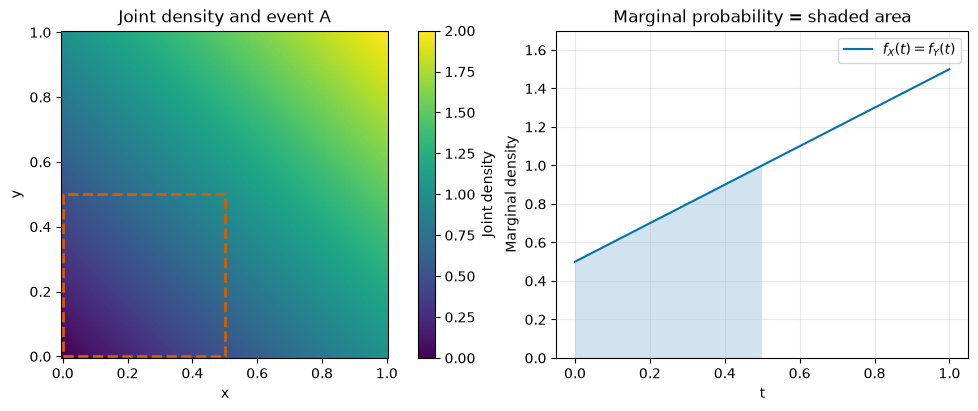

In [8]:
# 先对矩形事件直接积分，再分别画联合密度和边缘密度。
rectangle_probability, _ = dblquad(lambda y, x: joint_density(x, y), 0, 0.5, 0, 0.5)
print("区域概率、手算值与边缘乘积：", rectangle_probability, 1 / 8, (3 / 8) ** 2)  # 预期约为 0.125 0.125 0.140625。

axis_values = np.linspace(0, 1, 101)
mesh_x, mesh_y = np.meshgrid(axis_values, axis_values)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
color_plot = axes[0].pcolormesh(
    mesh_x, mesh_y, mesh_x + mesh_y, shading="auto", cmap="viridis"
)
# 橙色边框是积分区域，不是密度的等高线。
axes[0].plot([0, 0.5, 0.5, 0, 0], [0, 0, 0.5, 0.5, 0], "--", color="#D55E00", lw=2)
axes[0].set(xlabel="x", ylabel="y", title="Joint density and event A")
axes[0].set_aspect("equal")
fig.colorbar(color_plot, ax=axes[0], label="Joint density")
axes[1].plot(axis_values, axis_values + 0.5, color="#0072B2", label=r"$f_X(t)=f_Y(t)$")
# 边缘图的阴影给出单变量事件概率，不能据此假定联合事件独立。
axes[1].fill_between(
    axis_values, axis_values + 0.5, where=axis_values <= 0.5, alpha=0.2
)
axes[1].set(
    xlabel="t",
    ylabel="Marginal density",
    title="Marginal probability = shaded area",
    ylim=(0, 1.7),
)
axes[1].legend()
axes[1].grid(alpha=0.25)
# 预期联合密度向右上增大；橙框圈定左下事件区域，边缘密度是从 0.5 升到 1.5 的直线。
plt.show()

## 3 期望与方差需要哪些条件

继续前自查：先从联合表中指出一个条件概率的分母，再为连续模型写出积分区域。边缘概率能否相乘，要由独立性判断。

### 3.1 期望是按概率加权

记 $\mu_X=\mathbb E[X]$ 为 $X$ 的期望。本章讨论有限期望，要求 $\mathbb E[|X|]<\infty$。离散情形是绝对加权和有限，连续情形是绝对值积分有限；分布已归一化并不自动保证这一条件。

对取实值的函数 $g$，当 $\mathbb E[|g(X,Y)|]<\infty$ 时，直接在联合分布上计算：

$$\mathbb E[g(X,Y)]=\sum_x\sum_y g(x,y)p_{XY}(x,y),$$

$$\mathbb E[g(X,Y)]=\iint_{\mathbb R^2}g(x,y)f_{XY}(x,y)\,dx\,dy.$$

两式分别用于离散模型和有联合密度的连续模型；求和遍历所有可能取值。本章的有限表与有界矩形例子，对所用多项式都满足条件。

回到任务表，$\mathbb E[X]=0\times0.2+1\times0.3+2\times0.5=1.3$，$\mathbb E[Y]=0.7$。乘积期望要用联合表：$\mathbb E[XY]=1\times1\times0.2+2\times1\times0.4=1$。

In [9]:
mean_x = np.sum(x_values * p_x)
mean_y = np.sum(y_values * p_y)
mean_xy = np.sum(x_values[:, None] * y_values[None, :] * joint)

print("E[X]、E[Y]、E[XY]：", mean_x, mean_y, mean_xy)  # 预期约为 1.3 0.7 1。
print("E[X]E[Y]：", mean_x * mean_y)  # 预期约为 0.91。
# 这个模型不独立，乘积期望不能直接换成期望的乘积。

E[X]、E[Y]、E[XY]： 1.3 0.7000000000000001 1.0
E[X]E[Y]： 0.9100000000000001


### 3.2 线性组合的期望

若 $X,Y$ 的绝对一阶矩有限，对实常数 $a,b,c$ 有

$$\mathbb E[aX+bY+c]=a\mathbb E[X]+b\mathbb E[Y]+c.$$

这是期望的线性性质，不要求独立。例如把每次返工记为 2 个成本单位，延期记为 5 个成本单位，固定成本记为 1，得到 $C=2X+5Y+1$，其期望为 $2\times1.3+5\times0.7+1=7.1$。

In [10]:
cost_table = 2 * x_values[:, None] + 5 * y_values[None, :] + 1
direct_cost = np.sum(cost_table * joint)
linear_cost = 2 * mean_x + 5 * mean_y + 1

print("联合表直接加权与线性计算：", direct_cost, linear_cost)  # 预期约为 7.1 7.1。

联合表直接加权与线性计算： 7.1 7.1000000000000005


### 3.3 二阶矩、方差与标准差

在 $\mathbb E[X^2]<\infty$ 时，方差与标准差分别为

$$\operatorname{Var}(X)=\mathbb E[(X-\mu_X)^2],\qquad
\sigma_X=\sqrt{\operatorname{Var}(X)}.$$

展开平方并用线性性质，得到

$$\operatorname{Var}(X)=\mathbb E[X^2]-2\mu_X\mathbb E[X]+\mu_X^2
=\mathbb E[X^2]-\mu_X^2.$$

任务模型中，$\mathbb E[X^2]=0^2\times0.2+1^2\times0.3+2^2\times0.5=2.3$，所以 $\operatorname{Var}(X)=2.3-1.3^2=0.61$；$\operatorname{Var}(Y)=0.7-0.7^2=0.21$。方差的单位是原变量单位的平方，标准差与原变量同单位。

由 Cauchy–Schwarz 不等式，$\mathbb E[|X|]\le\sqrt{\mathbb E[X^2]}$，所以二阶矩有限能保证绝对一阶矩有限。某个有限样本算出有限数值，不能据此断言总体的方差存在。

In [11]:
variance_x = np.sum((x_values - mean_x) ** 2 * p_x)
variance_y = np.sum((y_values - mean_y) ** 2 * p_y)
second_moment_x = np.sum(x_values**2 * p_x)

print("X 的两种方差算法：", variance_x, second_moment_x - mean_x**2)  # 预期约为 0.61 0.61。
print("Y 的方差：", variance_y)  # 预期约为 0.21。
print("X、Y 的标准差：", np.sqrt([variance_x, variance_y]))  # 预期约为 [0.781025 0.458258]。
# 对这张已知概率表，使用概率加权；不是对取值列表调用无权样本方差。

X 的两种方差算法： 0.6100000000000001 0.6099999999999997
Y 的方差： 0.21000000000000002
X、Y 的标准差： [0.78102497 0.45825757]


## 4 协方差、相关与独立

### 4.1 协方差保留共同偏离的方向

本章要求 $X,Y$ 的二阶矩都有限，以保证协方差是有限实数。协方差（covariance）定义为

$$\operatorname{Cov}(X,Y)=\mathbb E[(X-\mu_X)(Y-\mu_Y)].$$

两个偏差同号时乘积为正，异号时为负；协方差是这些乘积的加权平均。展开后得到便于核对的形式：

$$\begin{aligned}
\operatorname{Cov}(X,Y)
&=\mathbb E[XY]-\mu_X\mathbb E[Y]-\mu_Y\mathbb E[X]+\mu_X\mu_Y\\
&=\mathbb E[XY]-\mu_X\mu_Y.
\end{aligned}$$

任务模型的协方差为 $1-1.3\times0.7=0.09$，单位是返工次数与延期指标单位的乘积。它表示平均的共同变化，不保证每个任务都沿同一方向变化。

对实常数 $a,b,c$，展开中心化后的平方还得到 $\operatorname{Var}(aX+bY+c)=a^2\operatorname{Var}(X)+b^2\operatorname{Var}(Y)+2ab\operatorname{Cov}(X,Y)$。因此计算成本 $C=2X+5Y+1$ 的方差时，必须保留共同变化项。

In [12]:
centered_products = (x_values[:, None] - mean_x) * (y_values[None, :] - mean_y)
covariance_xy = np.sum(centered_products * joint)

print("定义式与乘积期望式：", covariance_xy, mean_xy - mean_x * mean_y)  # 预期约为 0.09 0.09。

# 展开 (a(X-EX) + b(Y-EY))² 时，会多出 2ab Cov(X,Y)。
variance_cost = np.sum((cost_table - direct_cost) ** 2 * joint)
variance_cost_formula = 4 * variance_x + 25 * variance_y + 20 * covariance_xy
print("成本方差直接计算与展开计算：", variance_cost, variance_cost_formula)  # 预期约为 9.49 9.49。

定义式与乘积期望式： 0.09000000000000001 0.08999999999999986
成本方差直接计算与展开计算： 9.49 9.490000000000002


### 4.2 相关系数去除单位，但要求方差为正

当两者方差有限且严格大于 0 时，Pearson 相关系数为

$$\rho_{XY}=\frac{\operatorname{Cov}(X,Y)}{\sigma_X\sigma_Y},\qquad -1\le\rho_{XY}\le1.$$

它等于两个标准化变量的协方差，因而无量纲。将 $X$ 乘以正的单位换算系数，会同时改变协方差和 $\sigma_X$，比值保持不变。相关系数衡量线性关联，不概括所有形式的依赖。

若一个变量恒定，它的方差为 0，相关系数因分母为 0 而没有定义。此时协方差可以为 0，但不能把“相关系数无定义”写成“相关系数等于 0”。

In [13]:
correlation_xy = covariance_xy / np.sqrt(variance_x * variance_y)
scaled_correlation = (100 * covariance_xy) / np.sqrt(100**2 * variance_x * variance_y)

print("相关系数与正比例换单位后的值：", correlation_xy, scaled_correlation)  # 预期约为 0.251459 0.251459。
constant_variance = 0.0
print("常量变量的方差：", constant_variance)  # 常量变量的方差为 0。
# 常量变量的方差为零，相关系数分母也为零；此时相关系数没有定义。

相关系数与正比例换单位后的值： 0.2514594403022007 0.2514594403022007
常量变量的方差： 0.0


### 4.3 不相关不能反推出独立

若 $X,Y$ 独立且二阶矩有限，则 $\mathbb E[XY]=\mathbb E[X]\mathbb E[Y]$，于是协方差为 0。称协方差为 0 的变量不相关（uncorrelated）。

反方向不成立。另取随机变量 $U$，使它在 $-1,0,1$ 上各以 $1/3$ 的概率取值，并令 $V=U^2$。有

$$\mathbb E[U]=0,\qquad \mathbb E[V]=\frac23,\qquad
\mathbb E[UV]=\mathbb E[U^3]=0,$$

所以 $\operatorname{Cov}(U,V)=0$。但 $P(V=0\mid U=0)=1$，而 $P(V=0)=1/3$，两者明显不独立。这里非线性关系非常确定，线性协方差却恰好抵消。

In [14]:
u_values = np.array([-1.0, 0.0, 1.0])
v_values = u_values**2
weights = np.full(3, 1 / 3)
mean_u = np.sum(weights * u_values)
mean_v = np.sum(weights * v_values)
covariance_uv = np.sum(weights * (u_values - mean_u) * (v_values - mean_v))

print("Cov(U,V)：", covariance_uv)  # 预期为 0。
print("P(V=0)：", weights[v_values == 0].sum())  # 预期约为 0.333333。
print("P(V=0 | U=0)：", 1.0)  # 预期为 1；U=0 时 V=U² 必为 0。
# 这是对全部离散结果的计算，不是模拟样本中碰巧接近零。

Cov(U,V)： 0.0
P(V=0)： 0.3333333333333333
P(V=0 | U=0)： 1.0


## 5 随机向量与协方差矩阵

### 5.1 把两两协方差排成矩阵

随机向量 $Z=(Z_1,\ldots,Z_d)^T\in\mathbb R^d$ 把同一次观测的 $d$ 个分量排成列。各分量二阶矩有限时，定义均值向量 $\mu=\mathbb E[Z]\in\mathbb R^d$ 与协方差矩阵

$$\Sigma=\mathbb E[(Z-\mu)(Z-\mu)^T]\in\mathbb R^{d\times d},\qquad
\Sigma_{ij}=\operatorname{Cov}(Z_i,Z_j).$$

期望逐元素计算；对角线是方差。任务模型取 $Z=(X,Y)^T$，因此

$$\mu=\begin{bmatrix}1.3\\0.7\end{bmatrix},\qquad
\Sigma=\begin{bmatrix}0.61&0.09\\0.09&0.21\end{bmatrix}.$$

代码把六种可能结果排成一个 (6, 2) 数组，每行存一个数学列向量的分量；概率向量仍按联合表的行序展开。这样可直接把每个外积按对应概率加权。

In [15]:
# ij 索引与联合表的行 X、列 Y 一致，展开后各行结果与概率逐项对应。
outcomes_x, outcomes_y = np.meshgrid(x_values, y_values, indexing="ij")
outcomes = np.column_stack([outcomes_x.ravel(), outcomes_y.ravel()])
probabilities = joint.ravel()
mean_vector = probabilities @ outcomes
centered = outcomes - mean_vector
# probabilities[:, None] 为每行中心化向量加权，再计算两两分量乘积的期望。
covariance_matrix = centered.T @ (probabilities[:, None] * centered)

print("均值向量：", mean_vector)  # 预期约为 [1.3 0.7]。
print("协方差矩阵：\n", covariance_matrix)  # 预期约为 [[0.61 0.09] [0.09 0.21]]。
# 预期约为 [0.61 0.21] [0.61 0.21]。
print(
    "对角线与已算方差：", np.diag(covariance_matrix), np.array([variance_x, variance_y])
)

均值向量： [1.3 0.7]
协方差矩阵：
 [[0.61 0.09]
 [0.09 0.21]]
对角线与已算方差： [0.61 0.21] [0.61 0.21]


### 5.2 协方差矩阵为什么半正定

由于 $\operatorname{Cov}(Z_i,Z_j)=\operatorname{Cov}(Z_j,Z_i)$，$\Sigma$ 对称。对任意实列向量 $a\in\mathbb R^d$，有

$$a^T\Sigma a
=\mathbb E\!\left[(a^T(Z-\mu))^2\right]
=\operatorname{Var}(a^TZ)\ge0.$$

因此协方差矩阵总是半正定，但未必正定。若某个非零方向上的线性组合恒定，该方向的方差为 0。

更一般地，对固定矩阵 $A\in\mathbb R^{k\times d}$ 和固定向量 $b\in\mathbb R^k$，令 $W=AZ+b$，则

$$\mathbb E[W]=A\mu+b,\qquad
\operatorname{Cov}(W)=A\Sigma A^T.$$

后一式来自 $W-\mathbb E[W]=A(Z-\mu)$，把外积展开后将固定矩阵移到期望外。对 $C=2X+5Y+1$，它直接给出成本方差；固定成本不会增加方差。

In [16]:
cost_coefficients = np.array([2.0, 5.0])
print("协方差矩阵的特征值：", np.linalg.eigvalsh(covariance_matrix))  # 预期约为 [0.190683 0.629317]。
print("二次型计算成本方差：", cost_coefficients @ covariance_matrix @ cost_coefficients)  # 预期约为 9.49。

transform = np.array([[1.0, 0.0], [1.0, 1.0]])
# 每行存一个结果，所以右乘 transform.T；与数学列向量左乘矩阵的写法对应。
transformed_outcomes = outcomes @ transform.T
transformed_mean = probabilities @ transformed_outcomes
transformed_centered = transformed_outcomes - transformed_mean
# 分别按定义重新加权和按协方差变换公式计算，核对同一个矩阵。
direct_matrix = transformed_centered.T @ (probabilities[:, None] * transformed_centered)
formula_matrix = transform @ covariance_matrix @ transform.T
print("(X, X+Y) 的协方差矩阵：\n", formula_matrix)  # 预期约为 [[0.61 0.7 ] [0.7 1. ]]。
print("按定义与变换公式的最大差：", np.max(np.abs(direct_matrix - formula_matrix)))  # 本次数值约为 1.1e-16。

协方差矩阵的特征值： [0.19068288 0.62931712]
二次型计算成本方差： 9.49
(X, X+Y) 的协方差矩阵：
 [[0.61 0.7 ]
 [0.7  1.  ]]
按定义与变换公式的最大差： 1.1102230246251565e-16


## 6 条件期望是条件分布的加权平均

继续前自查：先说明零协方差为何不能推出独立，以及零方差时相关系数哪里失去定义；然后再把平均运算放到条件分布上。

### 6.1 先固定条件值

给定 $Y=y$ 后，用条件概率重新加权：

$$\mathbb E[X\mid Y=y]=\sum_x x\,p_{X\mid Y}(x\mid y),\qquad p_Y(y)>0.$$

在任务模型中，

$$\mathbb E[X\mid Y=0]=0\times\frac13+1\times\frac13+2\times\frac13=1,$$

$$\mathbb E[X\mid Y=1]=0\times\frac17+1\times\frac27+2\times\frac47=\frac{10}{7}.$$

给定一个具体的 $y$，条件期望是数值；把它记成函数 $m(y)$，则 $\mathbb E[X\mid Y]=m(Y)$ 是随 $Y$ 变化的随机变量。它描述同一条件下的平均值，不保证单次任务恰好取该值。

In [17]:
conditional_mean_x = x_values @ conditional_x
print("E[X | Y=0] 与 E[X | Y=1]：", conditional_mean_x)  # 预期约为 [1. 1.42857]。
print("两个条件均值对应的概率：", p_y)  # 预期约为 [0.3 0.7]。
# 条件平均可以是 10/7，即使 X 本身只取 0、1、2。

E[X | Y=0] 与 E[X | Y=1]： [1.         1.42857143]
两个条件均值对应的概率： [0.3 0.7]


### 6.2 再按条件的概率平均

当 $\mathbb E[|X|]<\infty$ 时，先求条件期望、再取期望会回到原期望：

$$\mathbb E[\mathbb E[X\mid Y]]=\mathbb E[X].$$

在离散表上，可以直接看出原因：

$$\sum_y\left[\sum_x x\frac{p_{XY}(x,y)}{p_Y(y)}\right]p_Y(y)
=\sum_x\sum_y x p_{XY}(x,y)=\mathbb E[X].$$

外层求和只取 $p_Y(y)>0$ 的条件值。本例为 $1\times0.3+(10/7)\times0.7=1.3$；不应把两个条件均值不加权地平均。

In [18]:
iterated_mean = conditional_mean_x @ p_y
print("按条件概率平均与原期望：", iterated_mean, mean_x)  # 预期约为 1.3 1.3。
print("不加权平均：", conditional_mean_x.mean())  # 预期约为 1.21429。
# 两种条件发生的概率不同，不加权平均会得到另一个数。

按条件概率平均与原期望： 1.3 1.3
不加权平均： 1.2142857142857142


### 6.3 连续条件需要密度比

回到单位正方形上的 $f_{XY}(x,y)=x+y$。给定满足 $f_X(x)>0$ 的位置 $x$，使用条件密度

$$f_{Y\mid X}(y\mid x)=\frac{f_{XY}(x,y)}{f_X(x)}
=\frac{x+y}{x+1/2},\qquad 0\le y\le1.$$

区间外为 0。对每个这样的 $x$，它关于 $y$ 的积分为 1。连续变量通常有 $P(X=x)=0$，这里不能套用“除以 $P(X=x)$”的离散事件比值；密度比给出条件分布的一种表示。

在相应绝对一阶矩有限时，条件期望是

$$m(x)=\mathbb E[Y\mid X=x]
=\frac{\int_0^1 y(x+y)\,dy}{x+1/2}
=\frac{x/2+1/3}{x+1/2}.$$

它不是边缘均值，也不是未归一化的切片积分。按 $f_X$ 再积分，得到 $\int_0^1m(x)f_X(x)dx=\int_0^1(x/2+1/3)dx=7/12=\mathbb E[Y]$。

In [19]:
def conditional_mean_y(x):
    return (x / 2 + 1 / 3) / (x + 0.5)


# 固定 x，对 y 积分；args 传固定条件，避免混淆条件值与积分变量。
for x in (0.0, 0.5, 1.0):
    mass, _ = quad(
        lambda y, fixed_x: joint_density(fixed_x, y) / marginal_density(fixed_x),
        0,
        1,
        args=(x,),
    )
    # 先核对条件密度积分为 1，再乘 y 求该条件下的均值。
    conditional_mean, _ = quad(
        lambda y, fixed_x: y * joint_density(fixed_x, y) / marginal_density(fixed_x),
        0,
        1,
        args=(x,),
    )
    # 三个密度积分均为 1；条件均值依次约为 0.666667、0.583333、0.555556。
    print(f"x={x:.1f}：条件密度积分={mass:.6f}，条件均值={conditional_mean:.6f}")

# 外层改对 x 积分，用边缘密度加权各条件均值。
continuous_iterated_mean, _ = quad(
    lambda x: conditional_mean_y(x) * marginal_density(x), 0, 1
)
print("连续模型的迭代期望与 7/12：", continuous_iterated_mean, 7 / 12)  # 预期约为 0.583333 0.583333。

x=0.0：条件密度积分=1.000000，条件均值=0.666667
x=0.5：条件密度积分=1.000000，条件均值=0.583333
x=1.0：条件密度积分=1.000000，条件均值=0.555556
连续模型的迭代期望与 7/12： 0.5833333333333333 0.5833333333333334


## 7 二维正态密度与等密度椭圆

### 7.1 通常密度公式要求正定协方差

二维正态是多元正态分布在 $d=2$ 时的情形。令随机向量 $Z=(X,Y)^T$、均值 $\mu\in\mathbb R^2$，协方差 $\Sigma\in\mathbb R^{2\times2}$ 对称正定，则 $Z\sim\mathcal N(\mu,\Sigma)$ 的密度为

$$f_Z(z)=\frac{1}{2\pi\sqrt{\det\Sigma}}
\exp\!\left[-\frac12(z-\mu)^T\Sigma^{-1}(z-\mu)\right],\qquad z\in\mathbb R^2.$$

$\det\Sigma>0$，逆矩阵存在。$z$ 是具体位置，$Z$ 是随机向量，两者须区分。

写成方差和相关系数的形式，

$$\Sigma=\begin{bmatrix}\sigma_X^2&\rho\sigma_X\sigma_Y\\
\rho\sigma_X\sigma_Y&\sigma_Y^2\end{bmatrix},\qquad
\det\Sigma=\sigma_X^2\sigma_Y^2(1-\rho^2).$$

所以当 $\sigma_X,\sigma_Y>0$ 时，通常密度要求 $|\rho|<1$。下面取 $\mu=(0,0)^T$、$\Sigma=\begin{bmatrix}2&1.2\\1.2&1\end{bmatrix}$，核对公式与 SciPy 的 pdf。计算二次型时用解线性方程代替显式求逆。

In [20]:
normal_mean = np.array([0.0, 0.0])
normal_covariance = np.array([[2.0, 1.2], [1.2, 1.0]])
point = np.array([1.0, 0.5])
offset = point - normal_mean
# 解方程得到协方差逆作用于 offset 的结果，无须显式构造逆矩阵。
quadratic = offset @ np.linalg.solve(normal_covariance, offset)
determinant = np.linalg.det(normal_covariance)
manual_density = np.exp(-0.5 * quadratic) / (2 * np.pi * np.sqrt(determinant))
normal_distribution = multivariate_normal(mean=normal_mean, cov=normal_covariance)

print("协方差特征值与行列式：", np.linalg.eigvalsh(normal_covariance), determinant)  # 预期约为 [0.2 2.8] 0.56。
print("公式密度与 SciPy 密度：", manual_density, normal_distribution.pdf(point))  # 预期约为 0.162704 0.162704。
print("密度差：", abs(manual_density - normal_distribution.pdf(point)))  # 本次数值约为 2.8e-17。

协方差特征值与行列式： [0.2 2.8] 0.56
公式密度与 SciPy 密度： 0.16270362875762284 0.16270362875762281
密度差： 2.7755575615628914e-17


### 7.2 联合正态中的不相关与独立

在二维联合正态且 $\sigma_X,\sigma_Y>0$ 的前提下，若 $\rho=0$，协方差矩阵为对角矩阵。代入密度公式：

$$f_Z(x,y)=
\frac{e^{-(x-\mu_X)^2/(2\sigma_X^2)}}{\sqrt{2\pi}\sigma_X}
\frac{e^{-(y-\mu_Y)^2/(2\sigma_Y^2)}}{\sqrt{2\pi}\sigma_Y}
=f_X(x)f_Y(y).$$

因此这时不相关能推出独立。“联合正态”是关键前提；不能把该结论用于任意联合分布，也不能只检查两个边缘分别正态就代替这个前提。

In [21]:
diagonal_covariance = np.diag([2.0, 1.0])
joint_normal_value = multivariate_normal.pdf(
    point, mean=normal_mean, cov=diagonal_covariance
)
marginal_factors = np.exp(-0.5 * point**2 / np.diag(diagonal_covariance)) / np.sqrt(
    2 * np.pi * np.diag(diagonal_covariance)
)
# 预期约为 0.0773472 0.0773472。
print(
    "对角协方差下的联合密度与两个一维密度乘积：",
    joint_normal_value,
    marginal_factors.prod(),
)
# 单点数值核对用于检查公式实现；独立性来自上面的恒等分解。

对角协方差下的联合密度与两个一维密度乘积： 0.0773472189519203 0.07734721895192032


### 7.3 特征值决定伸展，特征向量决定方向

对正定的 $\Sigma$ 作正交特征分解 $\Sigma=Q\Lambda Q^T$。$Q\in\mathbb R^{2\times2}$ 的列是单位特征向量，$\Lambda=\operatorname{diag}(\lambda_1,\lambda_2)$ 且 $\lambda_i>0$。令旋转后的坐标 $u=Q^T(z-\mu)$，则

$$q(z)=(z-\mu)^T\Sigma^{-1}(z-\mu)
=\frac{u_1^2}{\lambda_1}+\frac{u_2^2}{\lambda_2}.$$

固定 $q(z)=r^2$，$r>0$，便得到以 $\mu$ 为中心的椭圆。两个半轴长是 $r\sqrt{\lambda_1}$ 与 $r\sqrt{\lambda_2}$，方向是 $Q$ 的两列。其参数式为

$$z(\theta)=\mu+Q\begin{bmatrix}r\sqrt{\lambda_1}\cos\theta\\r\sqrt{\lambda_2}\sin\theta\end{bmatrix},\qquad0\le\theta\le2\pi.$$

下面取 $r=2$，对应密度与峰值的比为 $e^{-2}$。这是一条等密度线；不要仅凭“2”把它叫作某个固定覆盖率的区间。np.linalg.eigh 按升序返回特征值，对应特征向量放在列中。

In [22]:
eigenvalues, eigenvectors = np.linalg.eigh(normal_covariance)
radius = 2.0
angles = np.linspace(0, 2 * np.pi, 241)
unit_circle = np.vstack([np.cos(angles), np.sin(angles)])
# 先按半轴长缩放单位圆的两行，再用特征向量旋转，最后平移到总体均值。
ellipse_offsets = eigenvectors @ (radius * np.sqrt(eigenvalues)[:, None] * unit_circle)
ellipse_points = (normal_mean[:, None] + ellipse_offsets).T
# 每列一个椭圆偏移点；沿坐标轴求和得到各点的二次型值。
ellipse_quadratic = np.sum(
    ellipse_offsets * np.linalg.solve(normal_covariance, ellipse_offsets), axis=0
)
density_ratio = normal_distribution.pdf(ellipse_points) / normal_distribution.pdf(
    normal_mean
)

print("两个半轴长：", radius * np.sqrt(eigenvalues))  # 预期约为 [0.894427 3.34664]。
print("椭圆上 q(z) 与 4 的最大差：", np.max(np.abs(ellipse_quadratic - radius**2)))  # 本次数值约为 3.1e-15。
print("密度比范围与 exp(-2)：", density_ratio.min(), density_ratio.max(), np.exp(-2))  # 预期约为 0.135335 0.135335 0.135335。

两个半轴长： [0.89442719 3.34664011]
椭圆上 q(z) 与 4 的最大差： 3.1086244689504383e-15
密度比范围与 exp(-2)： 0.13533528323661245 0.13533528323661276 0.1353352832366127


### 7.4 退化分布不能直接套普通面积密度

若 $T\sim\mathcal N(0,1)$，令 $Z=(T,T)^T$，那么

$$\mu=0,\qquad\Sigma=\begin{bmatrix}1&1\\1&1\end{bmatrix}.$$

该矩阵半正定但不正定，特征值为 0 和 2。全部概率落在直线 $y=x$ 上；垂直方向的方差为 0。这是退化的二维正态分布，不能在通常二维面积密度公式中代入：行列式为 0，逆矩阵不存在。

直线在平面中的面积为 0，普通二维密度对它积分会给 0，无法表达这里概率为 1 的事实。仍可用一维变量 $T$ 描述和采样。SciPy 的 allow_singular=True 支持退化情形的专门约定，不能据此将结果当成普通二维面积密度。

下面只演示这个退化模型的支持位置；使用局部随机数生成器与固定种子，抽取 300 个独立同分布的一维标准正态值。散点是模拟，不是退化结论的证明。

特征值与行列式： [0. 2.] 0.0
所有样本的最大 |Y-X|： 0.0


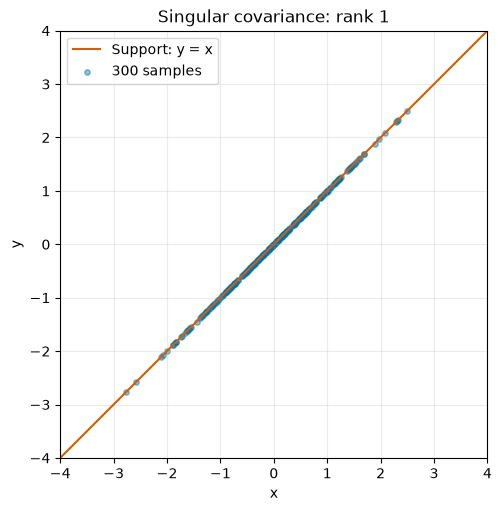

In [23]:
singular_covariance = np.array([[1.0, 1.0], [1.0, 1.0]])
singular_rng = np.random.default_rng(1704)
# 两列复用同一个一维随机样本，刻意构造 Y=X，不是独立抽取两列。
latent = singular_rng.standard_normal(300)
singular_samples = np.column_stack([latent, latent])

# 协方差的秩与样本差值从不同角度核对这个退化构造。
# 特征值为 [0, 2]，行列式为 0，均由给定协方差矩阵决定。
print(
    "特征值与行列式：",
    np.linalg.eigvalsh(singular_covariance),
    np.linalg.det(singular_covariance),
)
# 本例两列复用相同样本，所以每个点的 Y-X 都严格为 0。
print(
    "所有样本的最大 |Y-X|：",
    np.max(np.abs(singular_samples[:, 1] - singular_samples[:, 0])),
)

# 等比例坐标下，将全部样本与支持直线 y=x 叠加。
fig, ax = plt.subplots(figsize=(5, 5), layout="constrained")
ax.plot([-4, 4], [-4, 4], color="#D55E00", lw=1.5, label="Support: y = x")
ax.scatter(
    singular_samples[:, 0],
    singular_samples[:, 1],
    s=15,
    alpha=0.45,
    color="#0072B2",
    label="300 samples",
)
ax.set(
    xlim=(-4, 4),
    ylim=(-4, 4),
    xlabel="x",
    ylabel="y",
    title="Singular covariance: rank 1",
)
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.legend()
# 预期所有散点都落在 y=x 上，形成一条线而不是二维点云。
plt.show()

## 8 综合应用：从密度计算到样本形状

继续前自查：开始模拟前，先判断协方差矩阵是正定、仅半正定，还是不合法；只有正定情形才能直接套通常的二维面积密度公式。

### 8.1 用同一连续模型核对各个统计量

对单位正方形密度 $f_{XY}(x,y)=x+y$，已有 $f_X(x)=x+1/2$。从同一模型继续计算：

$$\mathbb E[X]=\int_0^1x(x+1/2)dx=\frac13+\frac14=\frac7{12},$$

$$\mathbb E[X^2]=\int_0^1x^2(x+1/2)dx=\frac14+\frac16=\frac5{12},$$

$$\mathbb E[XY]=\int_0^1\int_0^1xy(x+y)\,dy\,dx=\frac16+\frac16=\frac13.$$

由对称性，$Y$ 的同阶矩与 $X$ 相同。因此

$$\operatorname{Var}(X)=\operatorname{Var}(Y)=\frac{11}{144},\qquad
\operatorname{Cov}(X,Y)=-\frac1{144},\qquad \rho=-\frac1{11}.$$

把归一化、边缘、条件期望和二阶矩都建立在同一个联合密度上，才能保持这些计算相互一致。

In [24]:
continuous_mean, _ = quad(lambda x: x * marginal_density(x), 0, 1)
continuous_second, _ = quad(lambda x: x**2 * marginal_density(x), 0, 1)
continuous_product, _ = dblquad(lambda y, x: x * y * joint_density(x, y), 0, 1, 0, 1)
# 两条边缘相同，E[X]=E[Y]；由二阶矩减均值乘积得到方差和协方差。
continuous_variance = continuous_second - continuous_mean**2
continuous_covariance = continuous_product - continuous_mean**2
continuous_correlation = continuous_covariance / continuous_variance

numerical_moments = np.array(
    [
        continuous_mean,
        continuous_variance,
        continuous_covariance,
        continuous_correlation,
    ]
)
# 将数值积分结果与已手算的精确值按同一顺序对齐比较。
exact_moments = np.array([7 / 12, 11 / 144, -1 / 144, -1 / 11])
print("均值、方差、协方差、相关：", numerical_moments)  # 预期约为 [ 0.583333 0.0763889 -0.00694444 -0.0909091]。
print("与手算值的最大差：", np.max(np.abs(numerical_moments - exact_moments)))  # 本次数值约为 2.7e-15。
print("与条件期望再次平均的差：", abs(continuous_mean - continuous_iterated_mean))  # 预期接近 0；本次计算为 0。

均值、方差、协方差、相关： [ 0.58333333  0.07638889 -0.00694444 -0.09090909]
与手算值的最大差： 2.6506574712925612e-15
与条件期望再次平均的差： 0.0


### 8.2 先区分总体协方差与样本协方差

接着比较三个零均值二维正态模型：

$$\Sigma_1=\begin{bmatrix}1&0\\0&1\end{bmatrix},\quad
\Sigma_2=\begin{bmatrix}2&1.2\\1.2&1\end{bmatrix},\quad
\Sigma_3=\begin{bmatrix}2&-1.2\\-1.2&1\end{bmatrix}.$$

第一个等密度线是圆；后两个方差相同，协方差符号相反，预期伸展程度相同而方向不同。

每个模型独立同分布地模拟 $N=1500$ 个二维观测，只运行一批。对样本列向量 $z_1,\ldots,z_N$，样本均值与常用样本协方差为

$$\bar z=\frac1N\sum_{i=1}^N z_i,\qquad
S=\frac1{N-1}\sum_{i=1}^N(z_i-\bar z)(z_i-\bar z)^T.$$

总体矩阵 $\Sigma$ 是模型参数，$S$ 是本次样本的估计。代码每行一个观测，所以 np.cov 设置 rowvar=False；ddof=1 对应分母 $N-1$。固定种子方便复查，同一批有限模拟不证明任何总体结论，跨数值库构建也可能有小差异。

In [25]:
sample_count = 1500
rng = np.random.default_rng(1708)
covariance_cases = [
    np.eye(2),
    np.array([[2.0, 1.2], [1.2, 1.0]]),
    np.array([[2.0, -1.2], [-1.2, 1.0]]),
]
sample_cases = []

# 分别从三种已知总体协方差生成样本；每行一个观测，每列一个变量。
for case_number, covariance in enumerate(covariance_cases, start=1):
    samples = rng.multivariate_normal(
        [0.0, 0.0], covariance, size=sample_count
    )
    sample_cases.append(samples)
    # rowvar=False 按列识别变量；手写公式同样使用 n-1 作分母。
    sample_covariance = np.cov(samples, rowvar=False, ddof=1)
    sample_centered = samples - samples.mean(axis=0)
    manual_covariance = sample_centered.T @ sample_centered / (sample_count - 1)
    # 本次三组均值约为 [0.0356, 0.0239]、[-0.0227, -0.0122]、[-0.0219, -0.00024]，围绕总体零均值波动。
    print(f"模型 {case_number} 的样本均值：", samples.mean(axis=0))
    print("样本协方差：\n", sample_covariance)  # 本次三组协方差的非对角元约为 -0.00358、1.15278、-1.19382；分别对照理论 0、1.2、-1.2。
    # 与总体之差包含抽样波动；手写公式与库结果之差检查计算一致性。
    # 本次三组最大差约为 0.05466、0.07762、0.01858，样本矩阵不必等于总体矩阵。
    print("与总体矩阵的最大差：", np.max(np.abs(sample_covariance - covariance)))
    # 三次公式核对误差均接近 0，本次最大约 2.2e-16。
    print(
        "样本公式与 np.cov 的最大差：",
        np.max(np.abs(manual_covariance - sample_covariance)),
    )

模型 1 的样本均值： [0.03555247 0.02390435]
样本协方差：
 [[ 1.03509346 -0.00357713]
 [-0.00357713  0.94534342]]
与总体矩阵的最大差： 0.054656580796039855
样本公式与 np.cov 的最大差： 1.1102230246251565e-16
模型 2 的样本均值： [-0.02266891 -0.01218122]
样本协方差：
 [[1.92238456 1.15277805]
 [1.15277805 0.97308356]]
与总体矩阵的最大差： 0.0776154438565968
样本公式与 np.cov 的最大差： 2.220446049250313e-16
模型 3 的样本均值： [-0.02187846 -0.00024343]
样本协方差：
 [[ 2.00626192 -1.1938213 ]
 [-1.1938213   0.98142159]]
与总体矩阵的最大差： 0.01857840608048511
样本公式与 np.cov 的最大差： 0.0


### 8.3 在相同坐标范围比较样本与理论椭圆

下面叠加每个模型的 $q(z)=4$ 理论等密度线。曲线由模型的 $\Sigma$ 计算，不用样本协方差替换。三个子图使用相同坐标范围和等比例坐标，避免视觉上的伸缩掩盖差异。

同时打印特征值、半轴长及椭圆二次型残差。第二、第三个模型的特征值相同，协方差符号变化改变伸展方向；圆形模型的特征值相等，没有唯一的长轴方向。坐标均无量纲。

Isotropic：特征值=[1. 1.]，半轴长=[2. 2.]
  等密度线 q-4 最大绝对值： 8.881784197001252e-16
Positive covariance：特征值=[0.2 2.8]，半轴长=[0.89442719 3.34664011]
  等密度线 q-4 最大绝对值： 3.1086244689504383e-15
Negative covariance：特征值=[0.2 2.8]，半轴长=[0.89442719 3.34664011]
  等密度线 q-4 最大绝对值： 3.1086244689504383e-15


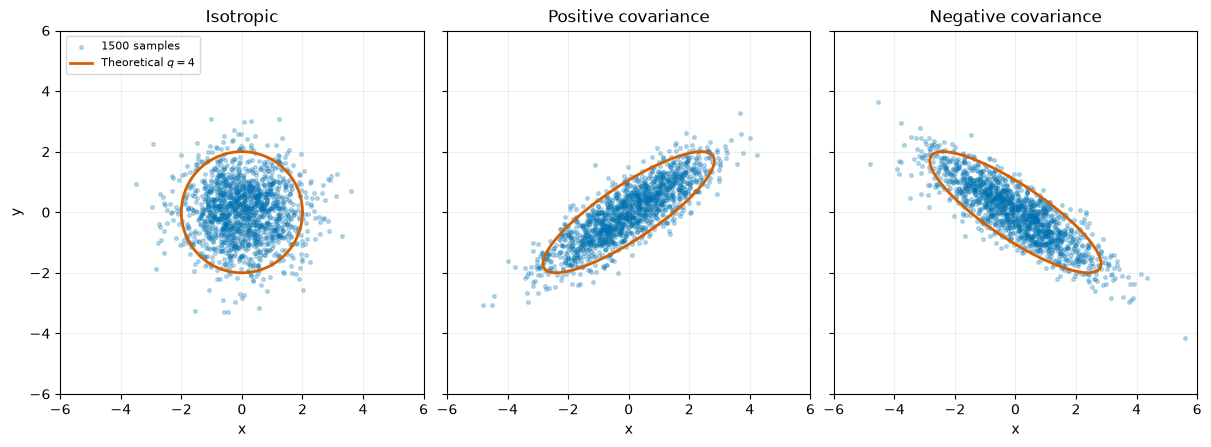

In [26]:
titles = ["Isotropic", "Positive covariance", "Negative covariance"]
fig, axes = plt.subplots(
    1, 3, figsize=(12, 4.3), sharex=True, sharey=True, layout="constrained"
)

for ax, title, covariance, samples in zip(
    axes, titles, covariance_cases, sample_cases
):
    # 先在特征方向上按半轴长度缩放单位圆，再旋转回原坐标。
    values, vectors = np.linalg.eigh(covariance)
    curve = vectors @ (radius * np.sqrt(values)[:, None] * unit_circle)
    # 每列是一个椭圆点，逐列代回二次型，核对同一个 q=4 水平。
    curve_quadratic = np.sum(curve * np.linalg.solve(covariance, curve), axis=0)
    print(f"{title}：特征值={values}，半轴长={radius * np.sqrt(values)}")  # 各向同性半轴均为 2；正、负协方差两组半轴均约 0.89443、3.34664。
    print("  等密度线 q-4 最大绝对值：", np.max(np.abs(curve_quadratic - 4)))  # 预期三条等密度线的残差接近 0；本次最大值均小于 1e-14。
    # 透明散点显示样本密集程度，实线给出总体模型的等密度椭圆。
    ax.scatter(
        samples[:, 0],
        samples[:, 1],
        s=7,
        alpha=0.25,
        color="#0072B2",
        label="1500 samples",
    )
    ax.plot(curve[0], curve[1], color="#D55E00", lw=2, label=r"Theoretical $q=4$")
    ax.set(xlim=(-6, 6), ylim=(-6, 6), xlabel="x", title=title)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("y")
axes[0].legend(loc="upper left", fontsize=8)
# 本次点云分别近圆形、沿右上方向拉长、沿右下方向拉长，与各自总体椭圆方向相符。
plt.show()

## 本章小结

（1）联合分布保留变量之间的搭配。边缘分布对另一个变量求和或积分；条件分布则固定条件，再按条件的总概率或边缘密度归一化。

（2）连续概率对应区域积分。闭矩形上连续函数可用两种累次积分顺序；密度、概率和积分的边界不能混淆。

（3）有限期望需要绝对一阶矩有限；有限方差与本章使用的协方差矩阵要求二阶矩有限。相关系数还要求方差非零。

（4）协方差矩阵把共同变化写成对称半正定矩阵。独立在矩条件满足时推出不相关，不相关一般不能反推独立。

（5）条件期望随条件值变化，再按条件的分布取平均可恢复原期望。二维正态的正定协方差决定等密度椭圆，奇异协方差需要按退化分布处理。

自查：只给两组边缘概率，能否恢复联合表？样本相关接近 0 能否证明独立？协方差矩阵合法，是否就一定能代入普通二维正态密度？

## 练习

先写清概率表的轴、积分范围和公式条件，再补全代码。每题保留独立代码单元，可在本章导入后运行。

（1）改变联合表

设 $X\in\{0,1,2\}$、$Y\in\{0,1\}$，联合表如下。计算边缘分布、$P(X=2\mid Y=1)$、$\mathbb E[X]$、$\operatorname{Cov}(X,Y)$，并检查 $\mathbb E[\mathbb E[X\mid Y]]=\mathbb E[X]$。判断独立性时，给出具体格子的比较，或核对完整乘积表。

可验证标准：总概率与每个条件分布的概率和为 1，两种期望算法一致。

In [27]:
exercise_joint = np.array([[2.0, 1.0], [1.0, 2.0], [1.0, 3.0]]) / 10
exercise_x = np.array([0.0, 1.0, 2.0])
exercise_y = np.array([0.0, 1.0])
# 补充边缘、条件、期望、协方差及独立性计算。

（2）改变矩形与归一化常数

设联合密度在 $[0,2]\times[0,1]$ 上为 $f_{XY}(x,y)=c(x+2y)$，其他位置为 0，其中 $c>0$。手算 $c$、两种边缘密度和 $P(X\le1,Y\le1/2)$，再用数值积分核对。说明 dblquad 的回调为何写成 (y, x)，并判断变量是否独立。

可验证标准：联合密度与每个边缘密度都归一化；事件概率在 0 和 1 之间，解析与数值结果在 $10^{-10}$ 内一致。

In [28]:
x_interval = (0.0, 2.0)
y_interval = (0.0, 1.0)
# 先手算 c，再写密度与积分；不要直接沿用单位正方形的边界。

（3）零协方差与零方差分别意味着什么

令 $U$ 在 $-2,0,2$ 上等概率取值，$V=U^2$，$W=3$ 为常量。分别计算 $\operatorname{Cov}(U,V)$、$\operatorname{Var}(V)$ 和 $\operatorname{Cov}(U,W)$。判断两对变量的相关系数是否有定义，并解释 $U,V$ 是否独立。

可验证标准：判断来自分布、条件概率和分母条件，不能只引用某个函数返回的 0 或缺失值。

In [29]:
exercise_u = np.array([-2.0, 0.0, 2.0])
exercise_v = exercise_u**2
exercise_w = np.full(3, 3.0)
exercise_weights = np.full(3, 1 / 3)
# 补充理论加权计算，并在分母为零时用文字说明相关系数无定义。

（4）先判断矩阵条件，再画正态图

考虑 $\Sigma(t)=\begin{bmatrix}1&t\\t&1\end{bmatrix}$，$t\in\mathbb R$。手算特征值，分别判断 $t=0,0.8,1,1.2$ 时是否能作为协方差矩阵、是否能使用通常二维密度公式。

对正定的两种情形，用固定种子各抽取 1000 个样本并叠加 $q=4$ 椭圆；对 $t=1$ 给出一维构造与支持位置；对不合法的情形解释负方向方差的矛盾，不进行采样。

可验证标准：区分半正定与正定，图形等比例，椭圆点代入二次型接近 4，模拟结论与理论结论分开陈述。

In [30]:
exercise_parameters = [0.0, 0.8, 1.0, 1.2]
exercise_rng = np.random.default_rng(1717)
# 先按特征值判断，再只对符合条件的模型继续采样与绘图。

## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：用理论概率 1/3 加权，不要引入样本方差的自由度修正。

提示 2：分别检查协方差的分子、相关系数的分母以及独立性的事件条件。

### 练习（3）参考解析

$E[U]=0$，$E[V]=8/3$，$E[UV]=E[U^3]=0$，所以 $\operatorname{Cov}(U,V)=0$。同时 $E[V^2]=32/3$，故 $\operatorname{Var}(V)=32/9$；$\operatorname{Var}(U)=8/3$。两者方差都为正，相关系数有定义且等于 0。

但 $P(V=0\mid U=0)=1$，而 $P(V=0)=1/3$，所以 U、V 不独立。常量 W 的方差为零，$\operatorname{Cov}(U,W)=0$，但 U、W 的相关系数分母为零，因而无定义。常量与 U 可以独立；这与相关系数是否有定义是不同问题。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MIT OpenCourseWare | Orloff、Bloom，18.05 Spring 2022：[Reading 7a](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class07-prep-a.pdf) §3.1–3.2、3.6–3.8、4，联合分布、边缘与独立；[Reading 7b](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class07-prep-b.pdf) §2–4，协方差、相关、单位及不相关反例。 |
| ProbabilityCourse | Pishro-Nik 著教材：[§5.1.1 Joint PMF](https://www.probabilitycourse.com/chapter5/5_1_1_joint_pmf.php) 联合表、边缘；[§5.1.3](https://www.probabilitycourse.com/chapter5/5_1_3_conditioning_independence.php) 条件 PMF、独立；[§5.1.5](https://www.probabilitycourse.com/chapter5/5_1_5_conditional_expectation.php) Conditional Expectation 与 Iterated Expectations；[§5.2.1](https://www.probabilitycourse.com/chapter5/5_2_1_joint_pdf.php) 联合密度、区域概率、边缘；[§5.2.3](https://www.probabilitycourse.com/chapter5/5_2_3_conditioning_independence.php) Conditioning by Another Random Variable；[§3.2.4](https://www.probabilitycourse.com/chapter3/3_2_4_variance.php) 方差与标准差；[§6.2.4](https://www.probabilitycourse.com/chapter6/6_2_4_cauchy_schwarz.php) Cauchy–Schwarz 不等式；[§6.1.5](https://www.probabilitycourse.com/chapter6/6_1_5_random_vectors.php) 随机向量、协方差矩阵、线性变换与半正定性质。 |
| StatLect | Taboga：[Expected value](https://www.statlect.com/fundamentals-of-probability/expected-value)，离散绝对可和、连续绝对可积条件与 The transformation theorem；[Properties of the expected value](https://www.statlect.com/fundamentals-of-probability/expected-value-properties) 的线性性质；[Covariance](https://www.statlect.com/fundamentals-of-probability/covariance)，Definition、An equivalent definition 与 Bilinearity。 |
| OpenStax | Calculus Volume 3，[§5.1 Double Integrals over Rectangular Regions](https://openstax.org/books/calculus-volume-3/pages/5-1-double-integrals-over-rectangular-regions)，二重积分的矩形分割定义与 Theorem 5.2：Fubini 定理的连续性条件、累次积分。 |
| Stanford CS229 | Chuong B. Do，[The Multivariate Gaussian Distribution](https://cs229.stanford.edu/section/gaussians.pdf)，§1、§4、附录 A.2：正定协方差下的密度、等密度椭圆与特征分解。 |
| University of Wisconsin–Madison | Jun Shao，Stat 609 [Lecture 15](https://pages.cs.wisc.edu/~shao/stat609/stat609-15.pdf)，第 1–4 页：奇异协方差的正态分布、低维表示、联合正态下不相关与独立。 |
| NumPy | 2.5 文档：[Generator.multivariate_normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.multivariate_normal.html) 的参数、样本形状与跨构建差异；[cov](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) 的 rowvar、ddof 及 Notes；[linalg.eigh](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html) 的特征值顺序与特征向量列布局。 |
| SciPy | 1.18 文档：[dblquad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.dblquad.html) 的回调顺序、积分边界、误差估计；[quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) 的单变量积分；[multivariate_normal](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.multivariate_normal.html) 的 pdf、正定与 allow_singular 条件。 |
| Matplotlib | 3.11 文档：[Axes.pcolormesh](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pcolormesh.html) 的网格与 shading；[Axes.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html) 的散点参数。 |